**Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.**

**Answer:**
Deep Learning is a subset of machine learning that uses neural networks with many layers (deep neural networks) to learn patterns from large amounts of data.

**Evolution:**
It evolved from simple neural networks → multilayer perceptrons → deep neural networks, supported by increased data, better algorithms, and powerful computing (GPUs).

**Difference from Traditional Machine Learning:**

* Deep Learning automatically extracts features from data
* Traditional ML requires manual feature engineering
* Deep Learning performs better on large, complex data (images, speech, text)

---

**Question 2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?**

**Answer:**
A Perceptron is a single-layer neural network used for binary classification.

**Architecture & Functioning:**

* Takes input values with weights
* Calculates weighted sum
* Applies activation function (step function)
* Produces output (0 or 1)

**Limitations:**

* Can only solve linearly separable problems
* Cannot handle complex patterns (e.g., XOR problem)
* Limited to binary classification
* No hidden layers, so low learning capability


**Question 3: Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.**

**Answer:**
Activation functions introduce non-linearity, allowing neural networks to learn complex patterns.

**Comparison:**

* **Sigmoid:** Output between 0 and 1; good for probability, but suffers from vanishing gradient.
* **Tanh:** Output between -1 and 1; better than sigmoid (zero-centered), but still has vanishing gradient issue.
* **ReLU (Rectified Linear Unit):** Output is 0 for negative and linear for positive; fast and widely used, but can suffer from “dead neurons”.

---

**Question 4: What is the difference between Loss function and Cost function in neural networks? Provide examples.**

**Answer:**

* **Loss Function:** Measures error for a single data point.
* **Cost Function:** Average of loss over the entire dataset.

**Examples:**

* Loss: Mean Squared Error (for one sample)
* Cost: Average Mean Squared Error over all samples
* Other examples: Cross-Entropy Loss

---

**Question 5: What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.**

**Answer:**
Optimizers update model weights to minimize the loss function.

**Comparison:**

* **Gradient Descent:** Updates weights using full dataset; simple but slow.
* **RMSprop:** Adjusts learning rate using moving average of squared gradients; faster convergence.
* **Adam:** Combines momentum and RMSprop; adaptive learning rate, widely used and efficient.


Question 6. Write a Python program to implement a single-layer perceptron from
scratch using NumPy to solve the logical AND gate.


In [1]:
import numpy as np

# Step function (activation)
def step_function(x):
    return 1 if x >= 0 else 0

# Training data for AND gate
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

# Initialize weights and bias
weights = np.zeros(2)
bias = 0
learning_rate = 0.1
epochs = 10

# Training the perceptron
for _ in range(epochs):
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step_function(linear_output)

        # Update rule
        error = y[i] - y_pred
        weights += learning_rate * error * X[i]
        bias += learning_rate * error

# Testing
print("Trained Weights:", weights)
print("Trained Bias:", bias)

print("\nPredictions:")
for x in X:
    output = step_function(np.dot(x, weights) + bias)
    print(f"{x} -> {output}")

Trained Weights: [0.2 0.1]
Trained Bias: -0.20000000000000004

Predictions:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


Question 7: Implement and visualize Sigmoid, ReLU, and Tanh activation functions
using Matplotlib.


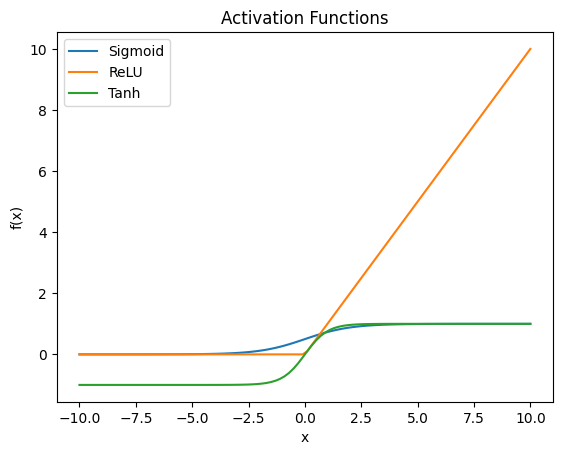

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate input values
x = np.linspace(-10, 10, 100)

# Activation functions
sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

# Plotting
plt.figure()
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, relu, label='ReLU')
plt.plot(x, tanh, label='Tanh')

plt.title("Activation Functions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()

plt.show()

Question 8: Use Keras to build and train a simple multilayer neural network on the
MNIST digits dataset. Print the training accuracy

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Build model
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(x_train, y_train, epochs=5, batch_size=32)

# Print training accuracy
print("Training Accuracy:", history.history['accuracy'][-1])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9316 - loss: 0.2352
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9696 - loss: 0.0990
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9782 - loss: 0.0695
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9829 - loss: 0.0536
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9869 - loss: 0.0413
Training Accuracy: 0.9868833422660828


Question 9: Visualize the loss and accuracy curves for a neural network model trained
on the Fashion MNIST dataset. Interpret the training behavior

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8235 - loss: 0.4934 - val_accuracy: 0.8467 - val_loss: 0.4183
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8637 - loss: 0.3735 - val_accuracy: 0.8594 - val_loss: 0.3884
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8784 - loss: 0.3325 - val_accuracy: 0.8613 - val_loss: 0.3802
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8855 - loss: 0.3116 - val_accuracy: 0.8755 - val_loss: 0.3467
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8921 - loss: 0.2925 - val_accuracy: 0.8763 - val_loss: 0.3384


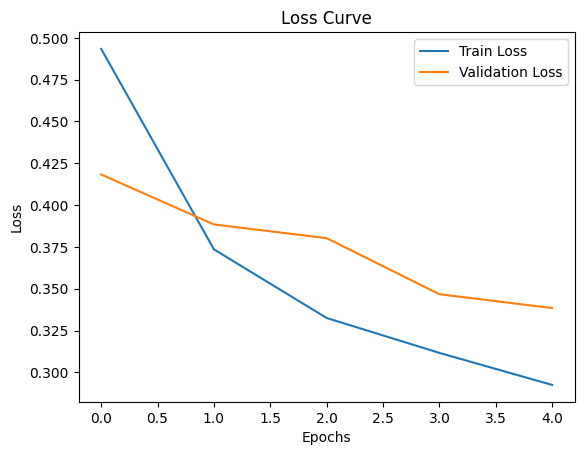

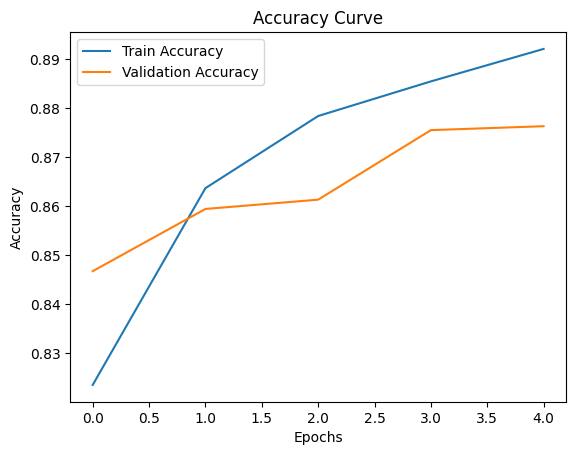

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Build model
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Plot Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

**Question 10: Fraud Detection – Real-Time Data Science Workflow**

---

### **1. Model Design (Multilayer Neural Network)**

* Use a **Multilayer Neural Network (MLP)** since data is structured.
* Input layer → takes features (amount, merchant ID, location, etc.)
* Hidden layers → 2–4 Dense layers (e.g., 64 → 32 → 16 neurons)
* Output layer → 1 neuron (binary classification: fraud or not)

👉 Perceptron is too simple; MLP captures complex patterns better.

---

### **2. Activation & Loss Function**

* **Hidden Layers:** ReLU → fast and handles non-linearity

* **Output Layer:** Sigmoid → gives probability (0 to 1)

* **Loss Function:**

  * Binary Cross-Entropy
    👉 Suitable for binary classification and probability outputs

---

### **3. Training & Evaluation (Handling Imbalanced Data)**

Since fraud cases are rare:

**Techniques:**

* Use **class weights** (give more importance to fraud class)
* Apply **oversampling (SMOTE)** or **undersampling**
* Use **stratified train-test split**

**Evaluation Metrics (instead of accuracy):**

* Precision (important: avoid false fraud alerts)
* Recall (important: detect actual frauds)
* F1-score
* ROC-AUC

---

### **4. Optimizer & Overfitting Prevention**

**Optimizer:**

* **Adam** → adaptive learning rate, fast convergence, widely used

**Prevent Overfitting:**

* Dropout layers (e.g., 0.3–0.5)
* Early stopping (stop when validation loss increases)
* Regularization (L2)
* Proper feature scaling
* Use validation set
